In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [34]:
model = YOLO('../models/yolov8n.pt')

3. Open video

In [3]:
video_path = "../videos/raw/test1.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error opening video")
else:
    print("Video loaded successfully")

Video loaded successfully


4. Reading frames of video

(1028, 1860, 3)


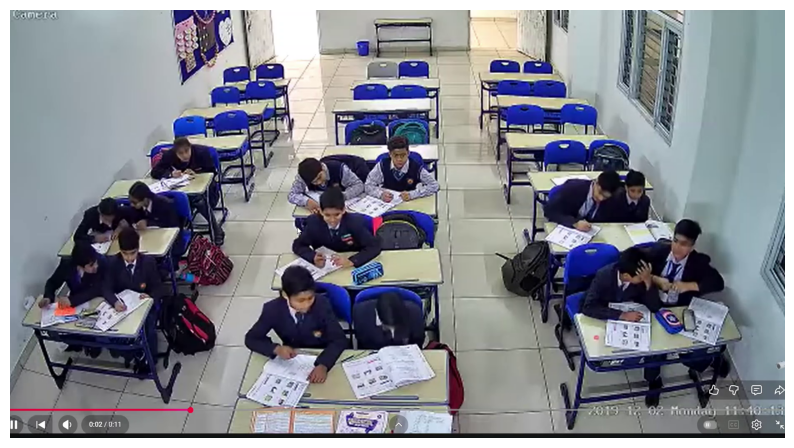

In [ ]:
# --> Testing (here in 1st 2 lines) if first frame is able to be read = done
ret, frame = cap.read() 
print(frame.shape) 

# --> now displaying them

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

In [ ]:
# 5. Running Yolo on single frame
results = model(frame)
results


0: 384x640 10 persons, 3 backpacks, 5 chairs, 1 laptop, 107.1ms
Speed: 9.0ms preprocess, 107.1ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

6. Extracting person detection only

In [10]:
for result in results:
    boxes = result.boxes
    
    for box in boxes:
        cls = int(box.cls[0])

        if cls == 0:
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

7. Displaying detection output

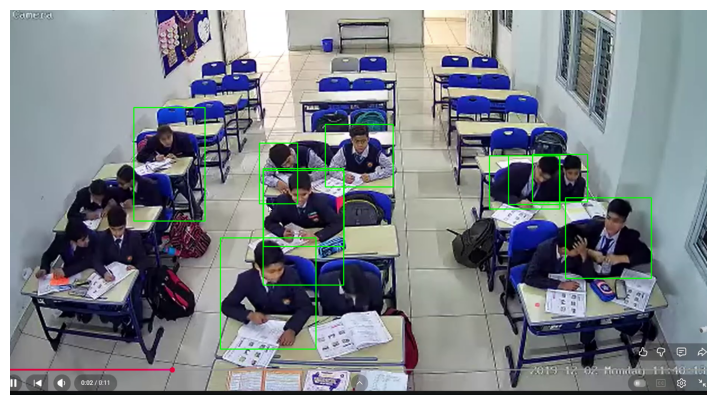

In [14]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

8. Re-open Video: 
Important because previous reads already consumed frames.

In [32]:
video_path = "../videos/raw/test1.mp4"

cap = cv2.VideoCapture(video_path)

9. Video processing loop

In [ ]:
while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    # Run YOLO inference
    results = model(frame)

    # Process detections
    for result in results:

        boxes = result.boxes

        for box in boxes:

            cls = int(box.cls[0])
            confidence = float(box.conf[0])

            label = f"Person {confidence:.2f}"

            # Detect only person class
            if cls == 0:

                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Draw rectangle
                cv2.rectangle(
                    frame,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )
                cv2.putText(
                    frame,
                    label,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

    # Inside your loop, before imshow:
    cv2.namedWindow("Person Detection", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Person Detection", 640, 480)

    # Display frame
    cv2.imshow("Person Detection", frame)

    # Press q to quit
    if cv2.waitKey(100) & 0xFF == ord('q'):
        break

cap.release()

cv2.destroyAllWindows()